In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
!pip install pretty_midi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 44.6 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.5 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=0dcbbfd9bf10a10d9a245beef7912f70a3e6f709ffc333eadff8b7fcf2f5b38d
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


In [2]:
import pretty_midi
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-05-05 20:17:19.891044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778012240.115461      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778012240.172936      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778012240.682704      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778012240.682740      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778012240.682743      57 computation_placer.cc:177] computation placer alr

In [3]:
import pretty_midi
import glob

TIME_SHIFT_BINS = 100
MAX_TIME_SHIFT = 1.0  # seconds

def midi_to_events(midi_file: str):
    pm = pretty_midi.PrettyMIDI(midi_file)
    
    if len(pm.instruments) == 0:
        return []
    
    instrument = pm.instruments[0]
    sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
    
    if len(sorted_notes) == 0:
        return []
    
    events = []
    prev_start = sorted_notes[0].start

    for note in sorted_notes:
        start = note.start
        end = note.end

        step = start - prev_start
        duration = end - start

        step_bin = int((step / MAX_TIME_SHIFT) * TIME_SHIFT_BINS)
        step_bin = max(0, min(TIME_SHIFT_BINS - 1, step_bin))

        duration_bin = int((duration / MAX_TIME_SHIFT) * TIME_SHIFT_BINS)
        duration_bin = max(0, min(TIME_SHIFT_BINS - 1, duration_bin))

        events.append(f"TIME_SHIFT_{step_bin}")
        events.append(f"NOTE_ON_{note.pitch}")
        events.append(f"TIME_SHIFT_{duration_bin}")
        events.append(f"NOTE_OFF_{note.pitch}")

        prev_start = start

    return events

In [4]:
midi_files = glob.glob("/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/*/*.midi", recursive=True) 
events = midi_to_events(midi_files[0])

print(events[:20])
print("Total events:", len(events))

['TIME_SHIFT_0', 'NOTE_ON_45', 'TIME_SHIFT_90', 'NOTE_OFF_45', 'TIME_SHIFT_13', 'NOTE_ON_72', 'TIME_SHIFT_12', 'NOTE_OFF_72', 'TIME_SHIFT_9', 'NOTE_ON_74', 'TIME_SHIFT_11', 'NOTE_OFF_74', 'TIME_SHIFT_9', 'NOTE_ON_76', 'TIME_SHIFT_11', 'NOTE_OFF_76', 'TIME_SHIFT_9', 'NOTE_ON_77', 'TIME_SHIFT_74', 'NOTE_OFF_77']
Total events: 6500


In [5]:
from collections import Counter
import glob

# Gather a small subset first for debugging
midi_files = glob.glob("/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0/*/*.midi", recursive=True)

print("Found MIDI files:", len(midi_files))

Found MIDI files: 1276


In [6]:
# Start small for debugging
debug_files = midi_files[:50]

all_event_sequences = []
all_tokens = []

for i, midi_path in enumerate(debug_files):
    try:
        events = midi_to_events(midi_path)
        if len(events) > 0:
            all_event_sequences.append(events)
            all_tokens.extend(events)
    except Exception as e:
        print(f"Skipping {midi_path}: {e}")

print("Usable files:", len(all_event_sequences))
print("Total tokens collected:", len(all_tokens))
print("Unique tokens:", len(set(all_tokens)))

Usable files: 50
Total tokens collected: 834312
Unique tokens: 274


In [7]:
special_tokens = ["<PAD>", "<START>", "<END>"]

vocab = special_tokens + sorted(set(all_tokens))
token_to_id = {tok: i for i, tok in enumerate(vocab)}
id_to_token = {i: tok for tok, i in token_to_id.items()}

print("Vocab size:", len(vocab))
print("First 20 vocab tokens:", vocab[:20])

Vocab size: 277
First 20 vocab tokens: ['<PAD>', '<START>', '<END>', 'NOTE_OFF_100', 'NOTE_OFF_101', 'NOTE_OFF_102', 'NOTE_OFF_103', 'NOTE_OFF_104', 'NOTE_OFF_105', 'NOTE_OFF_106', 'NOTE_OFF_107', 'NOTE_OFF_21', 'NOTE_OFF_22', 'NOTE_OFF_23', 'NOTE_OFF_24', 'NOTE_OFF_25', 'NOTE_OFF_26', 'NOTE_OFF_27', 'NOTE_OFF_28', 'NOTE_OFF_29']


In [8]:
encoded_example = [token_to_id["<START>"]] + \
                  [token_to_id[t] for t in all_event_sequences[0]] + \
                  [token_to_id["<END>"]]

print("First 30 encoded ids:", encoded_example[:30])
print("Encoded length:", len(encoded_example))

First 30 encoded ids: [1, 177, 122, 267, 35, 182, 149, 181, 62, 266, 151, 180, 64, 266, 153, 180, 66, 266, 154, 249, 67, 177, 134, 241, 47, 194, 149, 199, 62, 190]
Encoded length: 6502


In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

In [10]:
encoded_sequences = []

for events in all_event_sequences:
    encoded = [token_to_id["<START>"]] + \
              [token_to_id[t] for t in events] + \
              [token_to_id["<END>"]]
    encoded_sequences.append(encoded)

print("Total encoded sequences:", len(encoded_sequences))
print("Example sequence length:", len(encoded_sequences[0]))

Total encoded sequences: 50
Example sequence length: 6502


In [11]:
SEQ_LEN = 128
STRIDE = 64

samples = []

for seq in encoded_sequences:
    if len(seq) < SEQ_LEN + 1:
        continue
        
    for start in range(0, len(seq) - SEQ_LEN, STRIDE):
        chunk = seq[start:start + SEQ_LEN + 1]
        samples.append(chunk)

print("Total training samples:", len(samples))
print("Sample length:", len(samples[0]))

Total training samples: 12964
Sample length: 129


In [12]:
class MusicDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq = self.samples[idx]
        x = torch.tensor(seq[:-1], dtype=torch.long)   # input
        y = torch.tensor(seq[1:], dtype=torch.long)    # next-token target
        return x, y

In [13]:
dataset = MusicDataset(samples)
loader = DataLoader(dataset, batch_size=200, shuffle=True)

x_batch, y_batch = next(iter(loader))

print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)
print("First input sample:", x_batch[0][:20])
print("First target sample:", y_batch[0][:20])

x_batch shape: torch.Size([200, 128])
y_batch shape: torch.Size([200, 128])
First input sample: tensor([ 57, 177, 113, 211,  26, 189, 139, 180,  52, 190, 140, 211,  53, 187,
        137, 222,  50, 186, 113, 211])
First target sample: tensor([177, 113, 211,  26, 189, 139, 180,  52, 190, 140, 211,  53, 187, 137,
        222,  50, 186, 113, 211,  26])


In [14]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [15]:
class MusicTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=256,
        n_heads=4,
        n_layers=4,
        d_ff=512,
        max_seq_len=128,
        dropout=0.1
    ):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.max_seq_len = max_seq_len

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def generate_causal_mask(self, seq_len, device):
        mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device, dtype=torch.bool),
            diagonal=1
        )
        return mask

    def forward(self, x):
        batch_size, seq_len = x.shape
        device = x.device

        positions = torch.arange(0, seq_len, device=device).unsqueeze(0)
        x = self.token_emb(x) + self.pos_emb(positions)
        x = self.dropout(x)

        causal_mask = self.generate_causal_mask(seq_len, device)
        x = self.transformer(x, mask=causal_mask)

        x = self.ln_f(x)
        logits = self.head(x)
        return logits

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab_size = len(vocab)
model = MusicTransformer(
    vocab_size=vocab_size,
    d_model=256,
    n_heads=4,
    n_layers=4,
    d_ff=512,
    max_seq_len=SEQ_LEN,
    dropout=0.1
).to(device)

print(model)
print("Using device:", device)

MusicTransformer(
  (token_emb): Embedding(277, 256)
  (pos_emb): Embedding(128, 256)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=277, bias=True)
)
Using device: cuda


In [41]:
x_batch, y_batch = next(iter(loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

logits = model(x_batch)

print("Logits shape:", logits.shape)

Logits shape: torch.Size([200, 128, 277])


In [42]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

In [45]:
from torch.utils.data import random_split, DataLoader

# Split dataset
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=200, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=200, shuffle=False)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 10371
Val size: 2593


In [46]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device, epochs=20):
    train_losses = []
    val_losses = []
    train_mae = []
    val_mae = []

    for epoch in range(epochs):
        # Training
        model.train()
        total_train_loss = 0.0
        total_train_mae = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1)
            )

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)
            mae = torch.mean(torch.abs(preds.float() - y.float()))
            total_train_mae += mae.item()

        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_mae = total_train_mae / len(train_loader)

        # Validation
        model.eval()
        total_val_loss = 0.0
        total_val_mae = 0.0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                logits = model(x)

                loss = criterion(
                    logits.reshape(-1, logits.size(-1)),
                    y.reshape(-1)
                )

                total_val_loss += loss.item()

                preds = torch.argmax(logits, dim=-1)
                mae = torch.mean(torch.abs(preds.float() - y.float()))
                total_val_mae += mae.item()

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_mae = total_val_mae / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_mae.append(avg_train_mae)
        val_mae.append(avg_val_mae)

        print(
            f"Epoch {epoch+1} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Train MAE: {avg_train_mae:.4f} | "
            f"Val MAE: {avg_val_mae:.4f}"
        )

    return train_losses, val_losses, train_mae, val_mae

In [47]:
train_losses, val_losses, train_mae, val_mae = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=20
)

Epoch 1 | Train Loss: 2.1012 | Val Loss: 2.0406 | Train MAE: 13.3311 | Val MAE: 12.9572
Epoch 2 | Train Loss: 2.0877 | Val Loss: 2.0390 | Train MAE: 13.2673 | Val MAE: 12.8705
Epoch 3 | Train Loss: 2.0802 | Val Loss: 2.0360 | Train MAE: 13.2109 | Val MAE: 12.9464
Epoch 4 | Train Loss: 2.0725 | Val Loss: 2.0345 | Train MAE: 13.1592 | Val MAE: 12.9144
Epoch 5 | Train Loss: 2.0653 | Val Loss: 2.0299 | Train MAE: 13.0886 | Val MAE: 13.0699
Epoch 6 | Train Loss: 2.0583 | Val Loss: 2.0261 | Train MAE: 13.0756 | Val MAE: 12.9797
Epoch 7 | Train Loss: 2.0511 | Val Loss: 2.0223 | Train MAE: 13.0171 | Val MAE: 12.6700
Epoch 8 | Train Loss: 2.0447 | Val Loss: 2.0204 | Train MAE: 12.9719 | Val MAE: 12.8991
Epoch 9 | Train Loss: 2.0375 | Val Loss: 2.0156 | Train MAE: 12.9133 | Val MAE: 12.7480
Epoch 10 | Train Loss: 2.0303 | Val Loss: 2.0128 | Train MAE: 12.8718 | Val MAE: 12.8059
Epoch 11 | Train Loss: 2.0242 | Val Loss: 2.0104 | Train MAE: 12.8208 | Val MAE: 12.6035
Epoch 12 | Train Loss: 2.0187 

In [48]:
import torch
import torch.nn.functional as F

In [49]:
def sample_next_token(logits, temperature=0.5, top_k=20):
    logits = logits / temperature

    if top_k is not None:
        values, indices = torch.topk(logits, top_k)
        filtered_logits = torch.full_like(logits, float('-inf'))
        filtered_logits[indices] = values
        logits = filtered_logits

    probs = F.softmax(logits, dim=-1)
    next_token = torch.multinomial(probs, num_samples=1)
    return next_token.item()

In [50]:
def generate_tokens(
    model,
    token_to_id,
    id_to_token,
    target_notes=200,
    max_new_tokens=5000,
    seq_len=128,
    temperature=0.9,
    top_k=50,
    device="cuda"
):
    model.eval()

    start_id = token_to_id["<START>"]
    end_id = token_to_id["<END>"]
    pad_id = token_to_id["<PAD>"]

    generated = [start_id]
    note_count = 0

    with torch.no_grad():
        for _ in range(max_new_tokens):
            x = generated[-seq_len:]
            x = torch.tensor(x, dtype=torch.long, device=device).unsqueeze(0)

            logits = model(x)
            next_logits = logits[0, -1, :]

            # Block special tokens during generation
            next_logits[end_id] = -float("inf")
            next_logits[pad_id] = -float("inf")
            next_logits[start_id] = -float("inf")

            next_token = sample_next_token(
                next_logits,
                temperature=temperature,
                top_k=top_k
            )

            generated.append(next_token)

            token_name = id_to_token[next_token]

            if token_name.startswith("NOTE_ON"):
                note_count += 1

            if note_count >= target_notes:
                break

    print("Generated notes:", note_count)
    print("Generated tokens:", len(generated))

    return generated

In [51]:
generated_ids = generate_tokens(
    model,
    token_to_id,
    id_to_token,
    target_notes=200,
    max_new_tokens=5000,
    seq_len=SEQ_LEN,
    temperature=0.9,
    top_k=50,
    device=device
)

generated_tokens = [id_to_token[i] for i in generated_ids]

print(generated_tokens[:50])

Generated notes: 200
Generated tokens: 1108
['<START>', 'TIME_SHIFT_0', 'NOTE_ON_50', 'TIME_SHIFT_3', 'NOTE_OFF_50', 'TIME_SHIFT_0', 'NOTE_ON_59', 'TIME_SHIFT_5', 'NOTE_OFF_59', 'TIME_SHIFT_1', 'NOTE_ON_55', 'TIME_SHIFT_3', 'NOTE_OFF_55', 'TIME_SHIFT_11', 'NOTE_ON_67', 'TIME_SHIFT_3', 'NOTE_OFF_67', 'TIME_SHIFT_0', 'NOTE_ON_52', 'TIME_SHIFT_3', 'NOTE_OFF_52', 'TIME_SHIFT_1', 'NOTE_ON_58', 'TIME_SHIFT_4', 'NOTE_OFF_58', 'TIME_SHIFT_0', 'NOTE_ON_62', 'TIME_SHIFT_4', 'NOTE_OFF_62', 'TIME_SHIFT_9', 'NOTE_ON_74', 'TIME_SHIFT_5', 'NOTE_OFF_74', 'TIME_SHIFT_0', 'NOTE_ON_58', 'TIME_SHIFT_3', 'NOTE_OFF_58', 'TIME_SHIFT_1', 'NOTE_ON_70', 'TIME_SHIFT_4', 'NOTE_OFF_70', 'TIME_SHIFT_12', 'NOTE_ON_76', 'TIME_SHIFT_5', 'NOTE_OFF_76', 'TIME_SHIFT_1', 'NOTE_ON_70', 'TIME_SHIFT_3', 'NOTE_OFF_70', 'TIME_SHIFT_0']


In [52]:
import pretty_midi

In [53]:
def events_to_midi(events, output_path="generated.mid", default_velocity=100, default_duration=0.4):
    pm = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    current_time = 0.0
    active_notes = {}
    note_on_count = 0

    for event in events:
        if event in ["<START>", "<END>", "<PAD>"]:
            continue

        if event.startswith("TIME_SHIFT_"):
            shift_bin = int(event.split("_")[-1])
            shift_time = (shift_bin / TIME_SHIFT_BINS) * MAX_TIME_SHIFT
            current_time += shift_time

        elif event.startswith("NOTE_ON_"):
            pitch = int(event.split("_")[-1])
            note_on_count += 1

            # Create the note immediately so it does not get lost
            note = pretty_midi.Note(
                velocity=default_velocity,
                pitch=pitch,
                start=current_time,
                end=current_time + default_duration
            )

            instrument.notes.append(note)

            if pitch not in active_notes:
                active_notes[pitch] = []

            active_notes[pitch].append(note)

        elif event.startswith("NOTE_OFF_"):
            pitch = int(event.split("_")[-1])

            if pitch in active_notes and len(active_notes[pitch]) > 0:
                note = active_notes[pitch].pop(0)

                # Update note end time if valid
                if current_time > note.start:
                    note.end = current_time
                else:
                    note.end = note.start + default_duration

    pm.instruments.append(instrument)
    pm.write(output_path)

    print("NOTE_ON tokens found:", note_on_count)
    print("MIDI notes saved:", len(instrument.notes))

    return output_path

In [54]:
output_midi = events_to_midi(
    generated_tokens,
    output_path="/kaggle/working/generated_music.mid"
)

print("Saved to:", output_midi)

NOTE_ON tokens found: 200
MIDI notes saved: 200
Saved to: /kaggle/working/generated_music.mid


In [55]:
import matplotlib.pyplot as plt

In [56]:
train_losses
val_losses
train_mae
val_mae

[12.957207459669847,
 12.870472614581768,
 12.946365356445312,
 12.914354544419508,
 13.069898165189302,
 12.97973163311298,
 12.670012033902681,
 12.899088272681603,
 12.748000878554125,
 12.805851056025578,
 12.603469188396748,
 12.943322401780348,
 12.761080741882324,
 12.693487900954027,
 12.582627956683819,
 12.62770469372089,
 12.625149213350737,
 12.470417609581581,
 12.417742215670073,
 12.483723860520582]

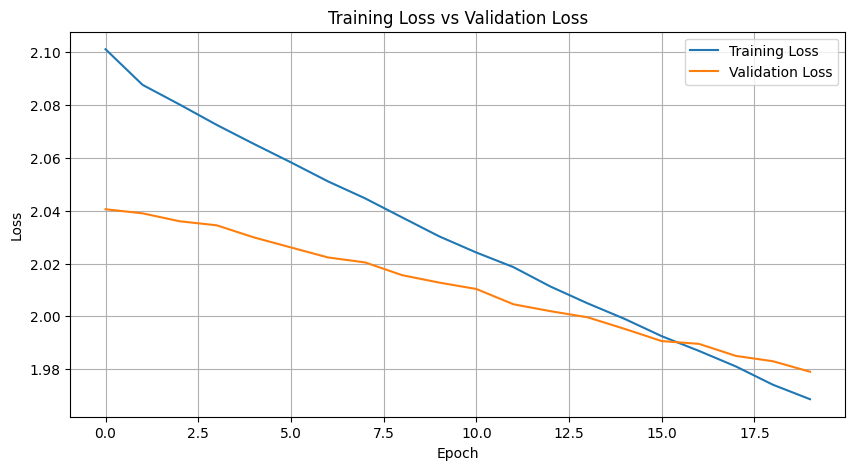

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

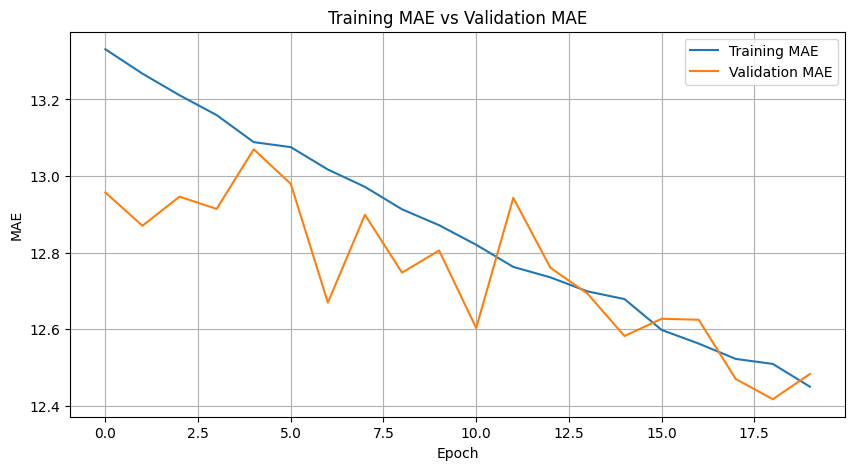

In [59]:
plt.figure(figsize=(10, 5))
plt.plot(train_mae, label="Training MAE")
plt.plot(val_mae, label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training MAE vs Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'val_mae' is not defined

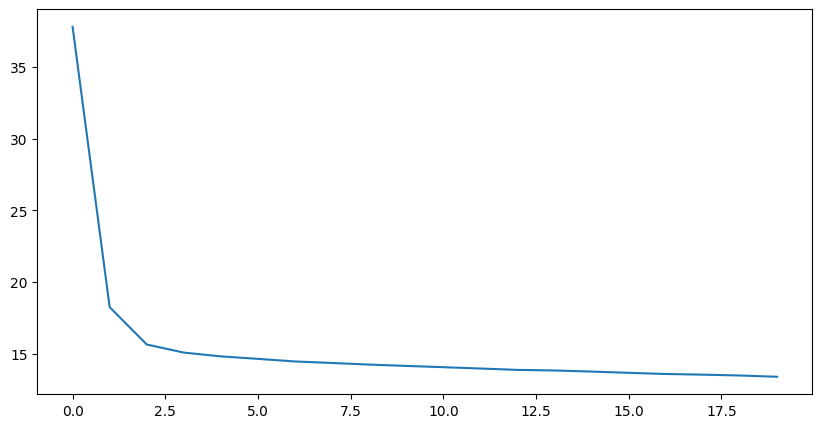

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(train_mae, label="Training MAE")
plt.plot(val_mae, label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training MAE vs Validation MAE")
plt.legend()
plt.grid(True)
plt.show()

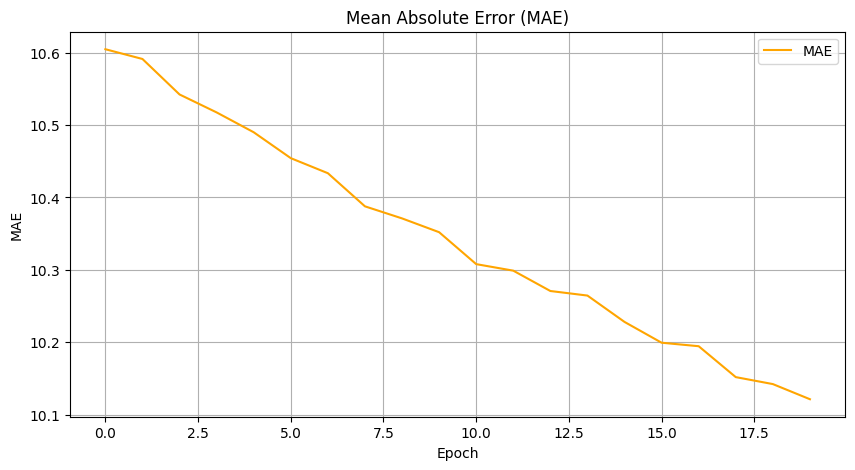

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_mae, label="MAE", color="orange")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE)")
plt.legend()
plt.grid(True)
plt.show()